## The problem with pure semantic search

When you query **"fish, onion"**, the sentence embedding model produces a single vector that captures the *combined meaning* of the phrase. But "onion" appears in ~80% of Indian recipes, so the query vector gets pulled toward generic onion dishes — and "fish" gets drowned out.

The fix: blend two independent signals.

```
final_score = (1 - w) × cosine_similarity  +  w × keyword_overlap
                    ↑                                  ↑
             semantic meaning              exact word match in ingredients
```

We will build each part from scratch.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sentence_transformers import SentenceTransformer

df = pd.read_csv('../Dataset/IndianFoodDatasetCSV.csv')
df = df.dropna(subset=['RecipeName', 'TranslatedIngredients']).reset_index(drop=True)
df['TranslatedIngredients'] = df['TranslatedIngredients'].fillna('')
df['Cuisine'] = df['Cuisine'].fillna('Unknown')
df['Diet']    = df['Diet'].fillna('Unknown')
df['Course']  = df['Course'].fillna('Unknown')
df['combined_text'] = (
    df['TranslatedRecipeName'].fillna('') + ' '
    + df['TranslatedIngredients'] + ' '
    + df['Cuisine'] + ' ' + df['Diet'] + ' ' + df['Course']
)
print(f'{len(df)} recipes loaded')

/home/achyutananda-sahoo/Desktop/SMAI-A3/Assignment-3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


6865 recipes loaded


---
## Part 1 — Cosine Similarity

### What is a vector?

The sentence transformer converts a text string into a list of numbers (a vector).  
Think of it as a point in 384-dimensional space where texts with similar meaning land close together.

### The formula

Given a query vector **q** and a recipe vector **r**, cosine similarity is:

$$\text{cosine\_sim}(q, r) = \frac{q \cdot r}{\|q\| \cdot \|r\|}$$

- **q · r** (dot product) = sum of element-wise products → measures how much the vectors point in the same direction
- **‖q‖** (norm) = length of vector q = √(sum of squares)
- Dividing by norms removes the effect of vector length — only **direction** matters
- Output range: **−1 to 1** (for text, usually 0 to 1)

### Tiny worked example (2D)

In [2]:
# 2D toy example so we can visualise
q = np.array([3.0, 2.0])   # query vector
r1 = np.array([4.0, 3.0])  # similar recipe (points in same direction)
r2 = np.array([1.0, 5.0])  # less similar recipe

def cosine_sim(a, b):
    dot     = np.dot(a, b)           # a · b
    norm_a  = np.linalg.norm(a)      # ‖a‖
    norm_b  = np.linalg.norm(b)      # ‖b‖
    return dot / (norm_a * norm_b)

print(f'q  = {q}')
print(f'r1 = {r1}  →  cosine_sim(q, r1) = {cosine_sim(q, r1):.4f}')
print(f'r2 = {r2}  →  cosine_sim(q, r2) = {cosine_sim(q, r2):.4f}')
print()
print('Dot product step by step:')
print(f'  q · r1 = {q[0]}×{r1[0]} + {q[1]}×{r1[1]} = {np.dot(q,r1)}')
print(f'  ‖q‖    = √({q[0]}² + {q[1]}²) = {np.linalg.norm(q):.4f}')
print(f'  ‖r1‖   = √({r1[0]}² + {r1[1]}²) = {np.linalg.norm(r1):.4f}')
print(f'  sim    = {np.dot(q,r1):.1f} / ({np.linalg.norm(q):.4f} × {np.linalg.norm(r1):.4f}) = {cosine_sim(q,r1):.4f}')

q  = [3. 2.]
r1 = [4. 3.]  →  cosine_sim(q, r1) = 0.9985
r2 = [1. 5.]  →  cosine_sim(q, r2) = 0.7071

Dot product step by step:
  q · r1 = 3.0×4.0 + 2.0×3.0 = 18.0
  ‖q‖    = √(3.0² + 2.0²) = 3.6056
  ‖r1‖   = √(4.0² + 3.0²) = 5.0000
  sim    = 18.0 / (3.6056 × 5.0000) = 0.9985


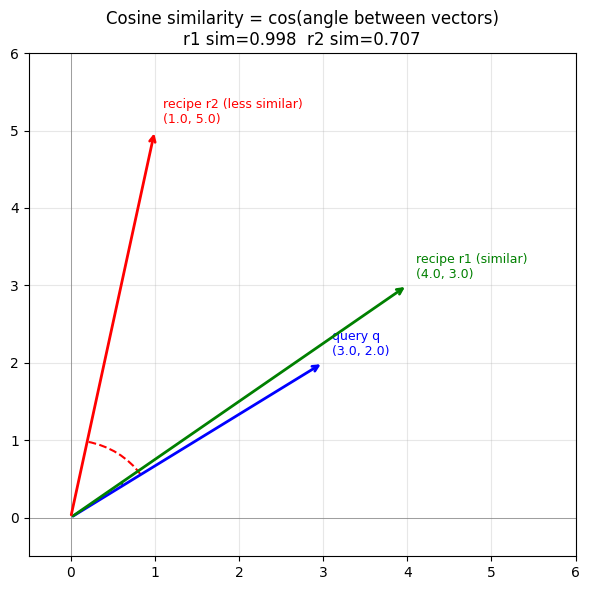

In [3]:
# Visualise the 2D vectors — same direction = high cosine sim
origin = np.array([0, 0])
fig, ax = plt.subplots(figsize=(6, 6))
for vec, label, color in [(q, 'query q', 'blue'), (r1, 'recipe r1 (similar)', 'green'), (r2, 'recipe r2 (less similar)', 'red')]:
    ax.annotate('', xy=vec, xytext=origin,
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.text(vec[0]+0.1, vec[1]+0.1, f'{label}\n({vec[0]}, {vec[1]})', color=color, fontsize=9)

# Draw angle arc between q and r1
angle_q  = np.degrees(np.arctan2(q[1], q[0]))
angle_r1 = np.degrees(np.arctan2(r1[1], r1[0]))
angle_r2 = np.degrees(np.arctan2(r2[1], r2[0]))
ax.add_patch(mpatches.Arc(origin, 1.5, 1.5, angle=0, theta1=min(angle_q,angle_r1), theta2=max(angle_q,angle_r1), color='green', lw=1.5, linestyle='--'))
ax.add_patch(mpatches.Arc(origin, 2.0, 2.0, angle=0, theta1=min(angle_q,angle_r2), theta2=max(angle_q,angle_r2), color='red',   lw=1.5, linestyle='--'))

ax.set_xlim(-0.5, 6); ax.set_ylim(-0.5, 6)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_title(f'Cosine similarity = cos(angle between vectors)\nr1 sim={cosine_sim(q,r1):.3f}  r2 sim={cosine_sim(q,r2):.3f}')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Now with real recipe embeddings

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

print('Embedding all recipes (takes ~20s)...')
embeddings = model.encode(df['combined_text'].tolist(), batch_size=64, show_progress_bar=True)
print(f'Shape: {embeddings.shape}')  # (6865, 384)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3636.14it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding all recipes (takes ~20s)...


Batches: 100%|██████████| 108/108 [00:19<00:00,  5.59it/s]


Shape: (6865, 384)


In [5]:
query = 'fish, onion'
query_vec = model.encode([query])   # shape (1, 384)

# cosine similarity — our formula applied to 384-D vectors
# sklearn does this efficiently for all N recipes at once
from sklearn.metrics.pairwise import cosine_similarity

cos_scores = cosine_similarity(query_vec, embeddings)[0]  # shape (N,)

print(f'Score range: {cos_scores.min():.3f} – {cos_scores.max():.3f}')
print(f'Mean score : {cos_scores.mean():.3f}')

top_idx = np.argsort(cos_scores)[::-1][:10]
print(f'\nTop 10 by cosine only:')
for i in top_idx:
    name  = df.loc[i, 'TranslatedRecipeName']
    ingr  = df.loc[i, 'TranslatedIngredients'][:60]
    print(f'  {cos_scores[i]:.3f}  {name[:45]:45s}  [{ingr}...]')

Score range: -0.128 – 0.486
Mean score : 0.221

Top 10 by cosine only:
  0.486  Onion Vegetable Recipe                         [15 Pearl onions (Sambar Onions) - peeled and halved,1/2 teas...]
  0.481  Chettinad Fish Fry With Roasted Corn, Onions   [1/2 kg Fish,4 teaspoon Red Chilli powder,4 teaspoon Coriande...]
  0.479  Tomato Onion Vegetable Recipe - Tomato Onion   [4 Tomatoes - quartered,1 Onion - thinly sliced,2 Green Chill...]
  0.477  Mexican Low Fat Fish Wraps Recipe              [1 Whole Wheat Flour Tortilla,200 grams Basa fish - boneless ...]
  0.469  Green Onion Recipe - Spring Onion Puri         [2 cups Whole Wheat Flour,1 tablespoon Sunflower Oil,1 teaspo...]
  0.463  Tomato Carrot Onion Soup Recipe - Healthy Tom  [1 tablespoon oil, 7 tomatoes - chopped, 1 onion - chopped, 1...]
  0.460   Spring Onion Potato Sabzi Recipe              [2 आलू,1 कप हरे प्याज के पत्ते - बारीक काट ले,4 कली लहसुन,2 स...]
  0.450  Spicy Chettinad Fish Fry Recipe                [4 Seer fish - stea

---
## Part 2 — Keyword Overlap Score

### The formula

Given a query with keywords **K = {k₁, k₂, …, kₙ}** and a recipe with ingredient text **I**:

$$\text{keyword\_score}(K, I) = \frac{|\{k \in K : k \subseteq I\}|}{|K|}$$

In plain English: **fraction of your query words that appear in the recipe's ingredients.**

| Query | Recipe ingredients | Score |
|---|---|---|
| fish, onion | …fish curry, onion, spices… | 2/2 = **1.0** |
| fish, onion | …onion, tomato, paneer… | 1/2 = **0.5** |
| fish, onion | …rice, dal, mustard… | 0/2 = **0.0** |

In [6]:
def keyword_scores(query: str, df: pd.DataFrame) -> np.ndarray:
    # Step 1: extract keywords — split on comma/space, drop very short words
    keywords = [w.lower().strip() for w in query.replace(',', ' ').split() if len(w) > 2]
    print(f'Keywords extracted: {keywords}')

    if not keywords:
        return np.zeros(len(df))

    # Step 2: for each recipe count how many keywords appear in its ingredients
    scores = np.array([
        sum(k in row.lower() for k in keywords) / len(keywords)
        for row in df['TranslatedIngredients']
    ])
    return scores

kw_scores = keyword_scores(query, df)

print(f'\nScore range: {kw_scores.min():.3f} – {kw_scores.max():.3f}')
print(f'Recipes with score 1.0 (all keywords matched): {(kw_scores == 1.0).sum()}')
print(f'Recipes with score > 0 (any keyword matched) : {(kw_scores > 0).sum()}')

top_kw_idx = np.argsort(kw_scores)[::-1][:10]
print(f'\nTop 10 by keyword only:')
for i in top_kw_idx:
    name = df.loc[i, 'TranslatedRecipeName']
    ingr = df.loc[i, 'TranslatedIngredients'][:60]
    print(f'  {kw_scores[i]:.2f}  {name[:45]:45s}  [{ingr}...]')

Keywords extracted: ['fish', 'onion']

Score range: 0.000 – 1.000
Recipes with score 1.0 (all keywords matched): 59
Recipes with score > 0 (any keyword matched) : 2688

Top 10 by keyword only:
  1.00  Fish Sukka Recipe - Fish With Spicy Masala Fi  [2 Fish - pompano (preferred),1 tablespoon Ginger Garlic Past...]
  1.00  Bengali Doi Maach Recipe (Fish In Yogurt Curr  [400 grams Rohu fish - sliced,1 Onion - sliced,6 cloves Garli...]
  1.00   Assamese Fish Fried Rice (Recipe In Hindi)    [2 cups rice - cook, 1 cup fish - cut in half, 1 onion - cut,...]
  1.00  Drunken Noodles Recipe - Pad Kee Mao           [200 grams Rice Noodles (Flat),1/2 cup Baby corn - cut into d...]
  1.00  Spicy Seafood Stew Casserole With Tomatoes An  [250 grams Fish fillet - basa,250 grams Prawns,15 Clamps,5 Ba...]
  1.00  Doi Ilish Recipe - Bengali Style Hilsa In Yog  [5 Fish - Ilish,1 cup Curd (Dahi / Yogurt) - whipped,2 teaspo...]
  1.00  Moroccan Baked Fish Recipe                     [500 grams Basa fish - sal

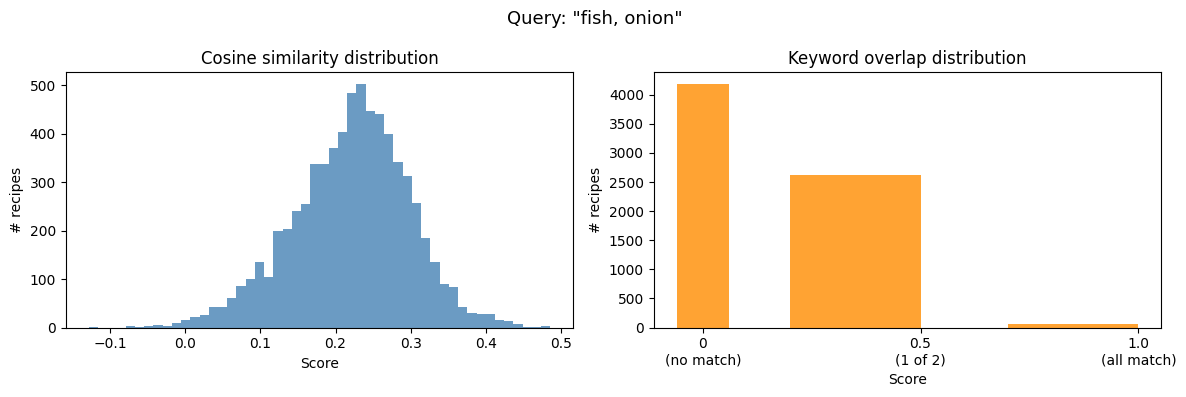

In [7]:
# Visualise score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cos_scores, bins=50, color='steelblue', alpha=0.8)
axes[0].set_title('Cosine similarity distribution')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('# recipes')

axes[1].hist(kw_scores, bins=[-0.1, 0.1, 0.6, 1.1], color='darkorange', alpha=0.8,
             rwidth=0.6, align='mid')
axes[1].set_xticks([0, 0.5, 1.0])
axes[1].set_xticklabels(['0\n(no match)', '0.5\n(1 of 2)', '1.0\n(all match)'])
axes[1].set_title('Keyword overlap distribution')
axes[1].set_xlabel('Score'); axes[1].set_ylabel('# recipes')

plt.suptitle(f'Query: "{query}"', fontsize=13)
plt.tight_layout(); plt.show()

---
## Part 3 — Blending the Two Scores

### The formula

$$\text{final\_score} = (1 - w) \times \text{cosine\_sim} \;+\; w \times \text{keyword\_overlap}$$

- **w = 0.0** → pure cosine similarity (ignores exact words)
- **w = 1.0** → pure keyword overlap (ignores meaning)
- **w = 0.35** → 65% semantic + 35% keyword (our default, works well in practice)

This is a **convex combination** — the weights sum to 1, so the output stays in [0, 1].

In [8]:
def blend(cos: np.ndarray, kw: np.ndarray, w: float) -> np.ndarray:
    return (1 - w) * cos + w * kw

# Show how results change as w varies
weights = [0.0, 0.2, 0.35, 0.5, 0.8, 1.0]

print(f'Query: "{query}"')
print(f'{"Weight w":>10}  {"Top-1 result":50s}  Score')
print('-' * 80)
for w in weights:
    scores  = blend(cos_scores, kw_scores, w)
    best    = np.argmax(scores)
    name    = df.loc[best, 'TranslatedRecipeName']
    print(f'{w:>10.2f}  {name[:50]:50s}  {scores[best]:.4f}')

Query: "fish, onion"
  Weight w  Top-1 result                                        Score
--------------------------------------------------------------------------------
      0.00  Onion Vegetable Recipe                              0.4857
      0.20  Chettinad Fish Fry With Roasted Corn, Onions And C  0.5851
      0.35  Chettinad Fish Fry With Roasted Corn, Onions And C  0.6629
      0.50  Chettinad Fish Fry With Roasted Corn, Onions And C  0.7407
      0.80  Chettinad Fish Fry With Roasted Corn, Onions And C  0.8963
      1.00  Spicy Seafood Stew Casserole With Tomatoes And Lim  1.0000


/tmp/ipykernel_20974/1019533948.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


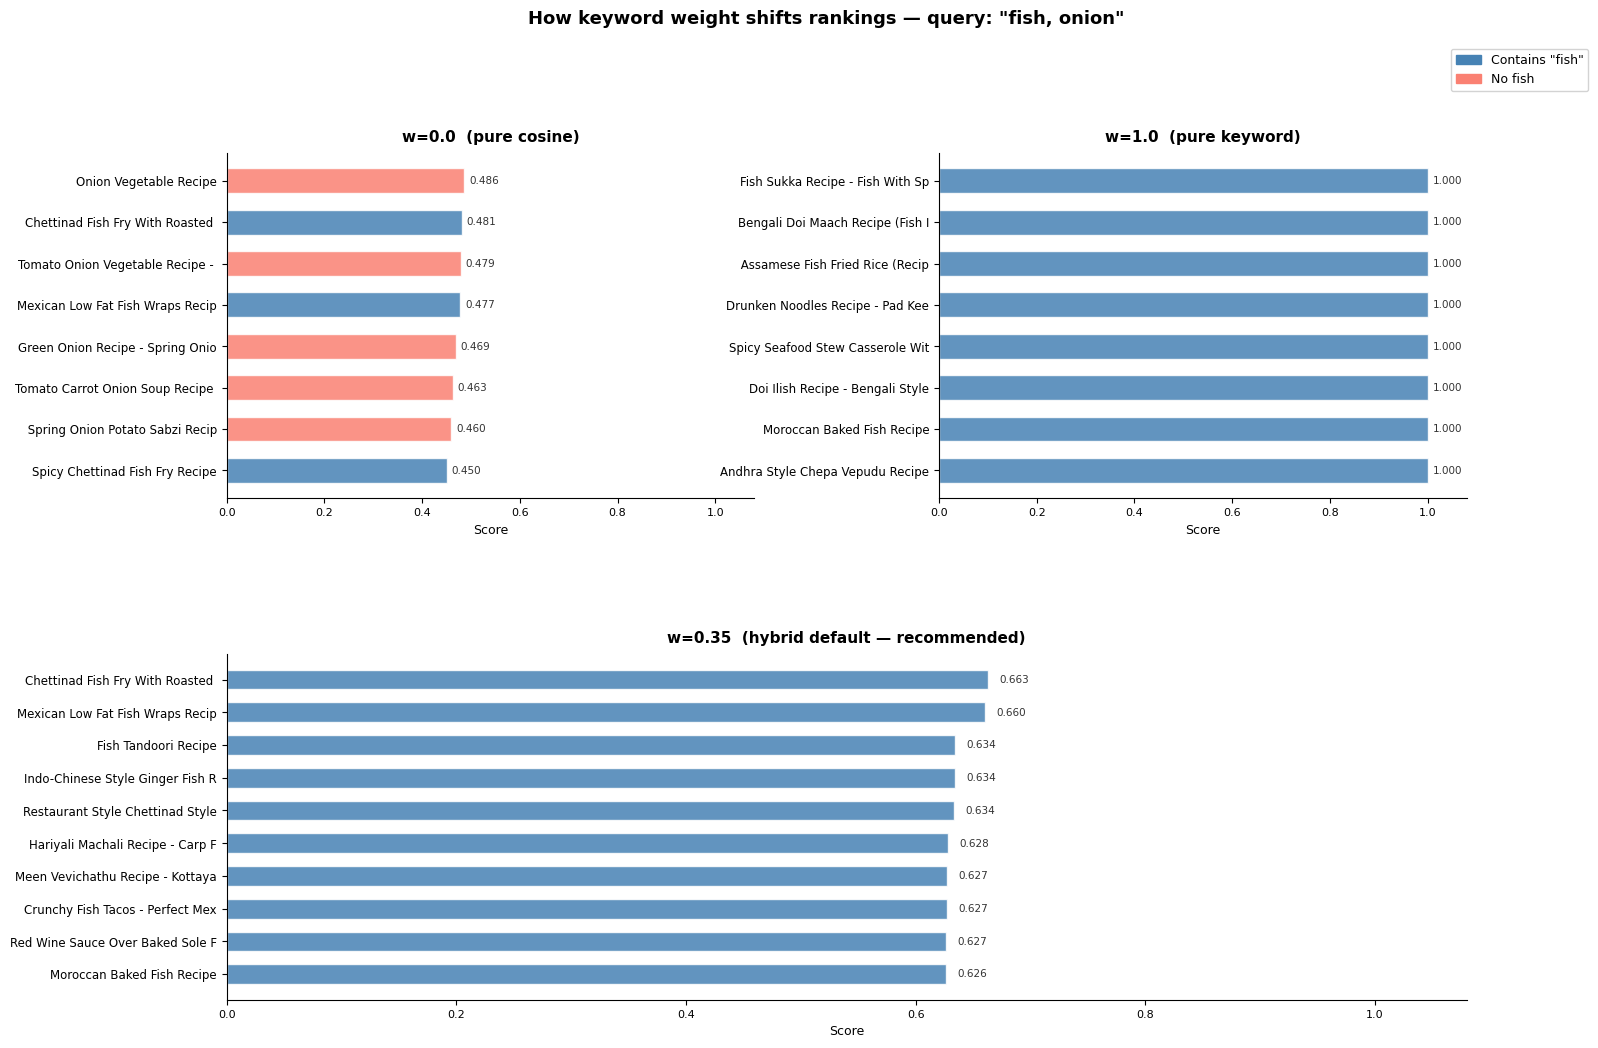

In [9]:
# Visualise how blending shifts the ranking
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 11))
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax_top_left  = fig.add_subplot(gs[0, 0])   # w=0.0
ax_top_right = fig.add_subplot(gs[0, 1])   # w=1.0
ax_bottom    = fig.add_subplot(gs[1, :])   # w=0.35  (full width)

panels = [
    (ax_top_left,  0.0,  'w=0.0  (pure cosine)',   8),
    (ax_top_right, 1.0,  'w=1.0  (pure keyword)',  8),
    (ax_bottom,    0.35, 'w=0.35  (hybrid default — recommended)', 10),
]

for ax, w, title, n in panels:
    scores  = blend(cos_scores, kw_scores, w)
    top_idx = np.argsort(scores)[::-1][:n]
    names   = [df.loc[i, 'TranslatedRecipeName'][:32] for i in top_idx]
    vals    = scores[top_idx]
    colors  = ['steelblue' if 'fish' in df.loc[i, 'TranslatedIngredients'].lower()
               else 'salmon' for i in top_idx]

    y = np.arange(len(names))
    bars = ax.barh(y[::-1], vals, color=colors, alpha=0.85, height=0.6, edgecolor='white')

    # value labels on bars
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=7.5, color='#333')

    ax.set_yticks(y[::-1])
    ax.set_yticklabels(names, fontsize=8.5)
    ax.set_xlim(0, 1.08)
    ax.set_xlabel('Score', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='x', labelsize=8)

# shared legend
legend_handles = [
    mpatches.Patch(color='steelblue', label='Contains \"fish\"'),
    mpatches.Patch(color='salmon',    label='No fish'),
]
fig.legend(handles=legend_handles, loc='upper right', fontsize=9,
           bbox_to_anchor=(0.98, 0.98), framealpha=0.85)

fig.suptitle(f'How keyword weight shifts rankings — query: \"{query}\"',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Part 4 — Full Pipeline (Brute-force, from scratch)

Putting it all together in one clean function — no libraries beyond numpy.

In [10]:
def recommend(
    query: str,
    df: pd.DataFrame,
    embeddings: np.ndarray,
    model,
    top_k: int = 10,
    kw_weight: float = 0.35
) -> pd.DataFrame:
    """
    Full hybrid recommendation pipeline.

    Steps:
      1. Embed query  →  query_vec  (shape: 1×384)
      2. Cosine similarity between query_vec and every recipe embedding
      3. Keyword overlap score for each recipe
      4. Blend: final = (1-w)*cosine + w*keyword
      5. Sort descending, return top_k
    """
    # ── Step 1: embed query ──────────────────────────────────────────
    query_vec = model.encode([query])                        # (1, 384)

    # ── Step 2: cosine similarity ────────────────────────────────────
    # Manual implementation (no sklearn)
    q_norm    = query_vec / np.linalg.norm(query_vec)        # unit vector
    e_norms   = np.linalg.norm(embeddings, axis=1, keepdims=True)  # (N,1)
    e_unit    = embeddings / e_norms                         # unit vectors (N,384)
    cos       = (e_unit @ q_norm.T).flatten()                # dot product → cosine sim (N,)

    # ── Step 3: keyword overlap ──────────────────────────────────────
    keywords  = [w.lower().strip() for w in query.replace(',', ' ').split() if len(w) > 2]
    if keywords:
        kw = np.array([
            sum(k in row.lower() for k in keywords) / len(keywords)
            for row in df['TranslatedIngredients']
        ])
    else:
        kw = np.zeros(len(df))

    # ── Step 4: blend ───────────────────────────────────────────────
    final = (1 - kw_weight) * cos + kw_weight * kw

    # ── Step 5: top-k ───────────────────────────────────────────────
    top_idx = np.argsort(final)[::-1][:top_k]
    results = df.iloc[top_idx][['TranslatedRecipeName', 'Cuisine', 'Diet', 'TotalTimeInMins', 'TranslatedIngredients']].copy()
    results['cosine_sim']      = cos[top_idx].round(3)
    results['keyword_overlap'] = kw[top_idx].round(3)
    results['final_score']     = final[top_idx].round(3)
    return results.reset_index(drop=True)


# Try it
results = recommend('fish, onion', df, embeddings, model, top_k=10, kw_weight=0.35)
results[['TranslatedRecipeName', 'cosine_sim', 'keyword_overlap', 'final_score']]

,TranslatedRecipeName,cosine_sim,keyword_overlap,final_score
0,"Chettinad Fish Fry With Roasted Corn, Onions A...",0.481,1.0,0.663
1,Mexican Low Fat Fish Wraps Recipe,0.477,1.0,0.660
2,Fish Tandoori Recipe,0.438,1.0,0.634
3,Indo-Chinese Style Ginger Fish Recipe,0.437,1.0,0.634
4,Restaurant Style Chettinad Style Fish Curry Re...,0.436,1.0,0.634
5,Hariyali Machali Recipe - Carp Fish In Green S...,0.427,1.0,0.628
6,Meen Vevichathu Recipe - Kottayam Style Fish C...,0.426,1.0,0.627
7,Crunchy Fish Tacos - Perfect Mexican Appetizer,0.426,1.0,0.627
8,Red Wine Sauce Over Baked Sole Fish Recipe,0.426,1.0,0.627
9,Moroccan Baked Fish Recipe,0.425,1.0,0.626


---
## Part 5 — Why the Math Works: Score Decomposition

For each result, we can see exactly how much of the score came from semantic vs keyword.

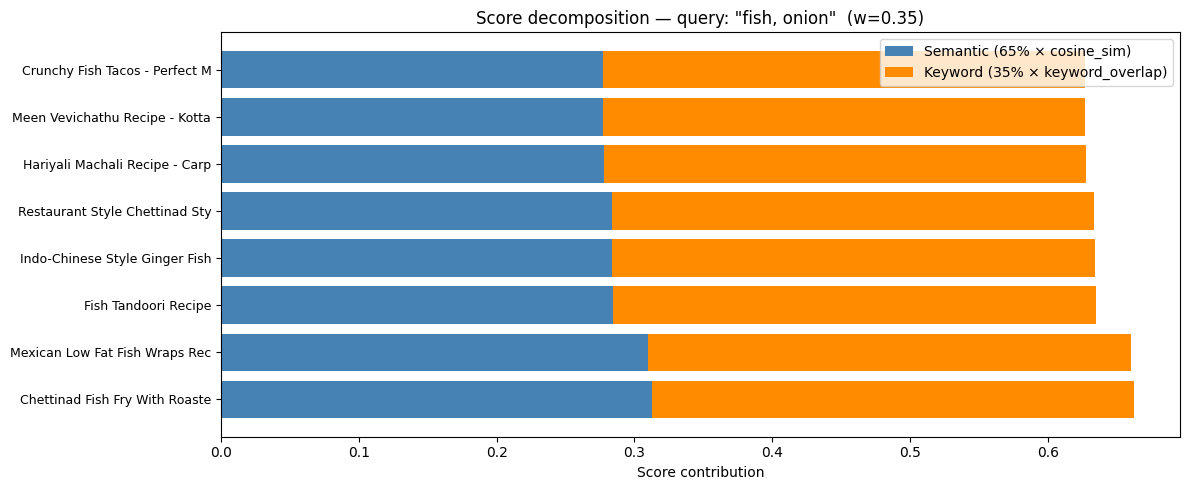


Detailed breakdown:
Recipe                                      Semantic     Keyword     Final
---------------------------------------------------------------------------
Chettinad Fish Fry With Roasted Corn, On       0.313       0.350     0.663
Mexican Low Fat Fish Wraps Recipe              0.310       0.350     0.660
Fish Tandoori Recipe                           0.285       0.350     0.635
Indo-Chinese Style Ginger Fish Recipe          0.284       0.350     0.634
Restaurant Style Chettinad Style Fish Cu       0.283       0.350     0.633
Hariyali Machali Recipe - Carp Fish In G       0.278       0.350     0.628
Meen Vevichathu Recipe - Kottayam Style        0.277       0.350     0.627
Crunchy Fish Tacos - Perfect Mexican App       0.277       0.350     0.627


In [11]:
W = 0.35
results = recommend('fish, onion', df, embeddings, model, top_k=8, kw_weight=W)

names        = [n[:30] for n in results['TranslatedRecipeName']]
sem_contrib  = (1 - W) * results['cosine_sim']      # semantic contribution
kw_contrib   = W       * results['keyword_overlap']  # keyword contribution

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(x, sem_contrib, color='steelblue', label=f'Semantic ({(1-W):.0%} × cosine_sim)')
ax.barh(x, kw_contrib,  left=sem_contrib, color='darkorange', label=f'Keyword ({W:.0%} × keyword_overlap)')

ax.set_yticks(x)
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('Score contribution')
ax.set_title(f'Score decomposition — query: "fish, onion"  (w={W})')
ax.legend()
plt.tight_layout(); plt.show()

print('\nDetailed breakdown:')
print(f'{"Recipe":40s}  {"Semantic":>10}  {"Keyword":>10}  {"Final":>8}')
print('-' * 75)
for _, row in results.iterrows():
    s = (1-W) * row['cosine_sim']
    k = W     * row['keyword_overlap']
    print(f"{row['TranslatedRecipeName'][:40]:40s}  {s:>10.3f}  {k:>10.3f}  {s+k:>8.3f}")

---
## Part 6 — Effect of Keyword Weight `w`

Sweep `w` from 0 to 1 and track whether the top result contains "fish".

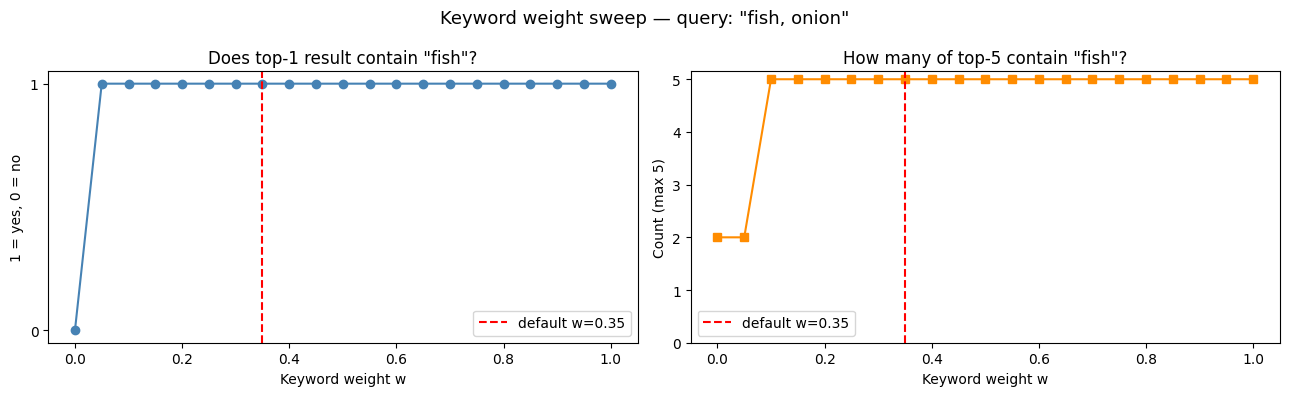

In [12]:
weights = np.arange(0, 1.05, 0.05)
fish_in_top1 = []
fish_in_top5 = []

for w in weights:
    res = recommend('fish, onion', df, embeddings, model, top_k=5, kw_weight=round(float(w), 2))
    top1_has_fish = 'fish' in res.iloc[0]['TranslatedIngredients'].lower()
    top5_fish_count = sum('fish' in r.lower() for r in res['TranslatedIngredients'])
    fish_in_top1.append(int(top1_has_fish))
    fish_in_top5.append(top5_fish_count)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(weights, fish_in_top1, 'o-', color='steelblue')
axes[0].set_xlabel('Keyword weight w'); axes[0].set_ylabel('1 = yes, 0 = no')
axes[0].set_title('Does top-1 result contain "fish"?')
axes[0].axvline(0.35, color='red', linestyle='--', label='default w=0.35')
axes[0].legend(); axes[0].set_yticks([0, 1])

axes[1].plot(weights, fish_in_top5, 's-', color='darkorange')
axes[1].set_xlabel('Keyword weight w'); axes[1].set_ylabel('Count (max 5)')
axes[1].set_title('How many of top-5 contain "fish"?')
axes[1].axvline(0.35, color='red', linestyle='--', label='default w=0.35')
axes[1].legend(); axes[1].set_yticks(range(6))

plt.suptitle('Keyword weight sweep — query: "fish, onion"', fontsize=13)
plt.tight_layout(); plt.show()

---
## Summary

| Component | Formula | What it captures |
|---|---|---|
| **Cosine similarity** | `(q·r) / (‖q‖·‖r‖)` | Semantic meaning — similar dishes even with different words |
| **Keyword overlap** | `matched_keywords / total_keywords` | Exact ingredient presence |
| **Hybrid blend** | `(1−w)·cosine + w·keyword` | Best of both |

**When to increase `w`:** specific ingredient queries like "fish, onion", "mango, coconut"  
**When to decrease `w`:** vague queries like "something spicy", "comfort food", "quick dinner"